In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
text = os.path.join('Datos','Transformados', "Vitoria_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [3]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [4]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [5]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [6]:
lines = " ".join(df['full_review'])

In [7]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [8]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [9]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [11]:
X.shape


(1202, 2458)

In [12]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [13]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


ubicación      239
cama           209
apartamento    182
bien           172
sofá           150
limpieza       126
limpio         103
cómodo          89
habitación      86
cocina          62
dtype: int64


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)

print(tf_matrix.head())


    00  00h  00la   04   10  100  100x  10min   11  11am  ...  íbamos  ídem  \
0  0.0  0.0   0.0  0.0  0.0  0.0   0.0    0.0  0.0   0.0  ...     0.0   0.0   
1  0.0  0.0   0.0  0.0  0.0  0.0   0.0    0.0  0.0   0.0  ...     0.0   0.0   
2  0.0  0.0   0.0  0.0  0.0  0.0   0.0    0.0  0.0   0.0  ...     0.0   0.0   
3  0.0  0.0   0.0  0.0  0.0  0.0   0.0    0.0  0.0   0.0  ...     0.0   0.0   
4  0.0  0.0   0.0  0.0  0.0  0.0   0.0    0.0  0.0   0.0  ...     0.0   0.0   

   óptima  óptimas  ósea  último  única  únicamente  único  útiles  
0     0.0      0.0   0.0     0.0    0.0         0.0    0.0     0.0  
1     0.0      0.0   0.0     0.0    0.0         0.0    0.0     0.0  
2     0.0      0.0   0.0     0.0    0.0         0.0    0.0     0.0  
3     0.0      0.0   0.0     0.0    0.0         0.0    0.0     0.0  
4     0.0      0.0   0.0     0.0    0.0         0.0    0.0     0.0  

[5 rows x 2458 columns]


In [15]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


ubicación      204
cama           179
apartamento    165
bien           156
sofá           132
limpieza       111
limpio          99
cómodo          86
habitación      81
buena           61
dtype: int64


In [16]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


útiles        7.091742
únicamente    7.091742
00h           7.091742
00la          7.091742
04            7.091742
vómito        7.091742
vía           7.091742
vuelvo        7.091742
vuelta        7.091742
vsisitar      7.091742
dtype: float64


In [17]:
tfidf_matrix0 = tf_matrix * idf_vector


In [18]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


fritas        0.506553
botellitas    0.506553
bolsita       0.506553
dos           0.505199
patatas       0.428081
pack          0.378570
pequeña       0.358021
dejan         0.342083
café          0.335275
cápsulas      0.323342
Name: 3, dtype: float64


In [19]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


942     7.091742
768     7.091742
291     7.091742
324     7.091742
293     7.091742
353     6.398595
1172    6.398595
40      5.705448
756     5.705448
933     5.482304
dtype: float64


In [20]:
average_score = sentence_scores.mean()
average_score

np.float64(1.098680027420695)

In [21]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [22]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 Tal cual se muestra en la foto. Todo muy bonito y cuidado al detalle. Está muy usado y es súper incómodo. No lo recomiendo para dormir. Hasta para sentarse se hunde. Los baños perfectos. Las camas bien. El olor a humo de la habitación. Personal amable. Todo un detalle. Gracias. Bien ubicado. Instalaciones nuevas y modernas. En todo momento, nuestras dudas fueron resueltas. Y la ubicación es perfecta. La echamos en falta. Estaba muy cuidado. Es muy cómodo y moderno. Ni un mísero detalle en la habitación. La ubicación. Un par de puntos a destacar:  1. Una pena. Código largo, etc,. Es el camino pero habría que darle una vuelta de tuerca. Decorado con gusto. todo en perfecto estado. limpieza espectacular. moderno y luminoso. se aparca en la calle sin pagar. me gustó todo de este apartamento. nos gustó mucho el alojamiento. Tenía de todo, muy completo. Todo muy limpio y ordenado. Hemos tenido que acceder con el código. Las almohadas son muy incómodas, extremadamente finas. Repetiremos segu

In [23]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 812

In [24]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [25]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


In [26]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
desayuno, horario, pueda, pueden, pena, aunque, dejan, justo, espacio, podría, día, jabón, edificio, alguna, mejor

Cluster 1 - Top 15 palabras clave:
bien, apartamento, habitación, recepción, si, limpieza, personal, falta, nadie, cocina, solo, baño, ducha, check, cama

Cluster 2 - Top 15 palabras clave:
cama, sofá, sofá cama, incómodo, cama incómodo, cómodo, cama cómodo, dormir, cama sofá, bastante, colchón, habitación, persona, colchón sofá, personas

Cluster 3 - Top 15 palabras clave:
ventanas, abrir, solo, piso, calor, aire, ser, café, gustado, pueda, pueden, decir, si, hacía, manera


In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: desayuno, decepcionante, pésimo, incluido, vale, prescindir, pack, vergüenza, continental, preparar, pueden, pena, dejan, considerar, incorrecta
Ejemplos de frases (5):
- El desayuno lo sirven en una cafetería independiente enfrente del edificio de apartamentos, aunque es cierto que desayunamos estupendamente.
- Muy muy JUSTo el espacio para preparar desayuno….
- No teníamos estropajos y jabón o alguna pastilla para dejar el desayuno fregado.
- Contratamos el desayuno, y no sabíamos dónde era, menos mal que vimos a una trabajadora del hotel, en un despacho en la entrada, y por casualidad, y muy amablemente nos informó.
- El desayuno es un pack que dejan en el apartamento.

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: bien, recepción, apartamento, habitación, limpieza, si, falta, nadie, personal, check, cama, ducha, cocina, solo, funcionaba
Ejemplos de frases (5):
- Está muy usado y es súper incómodo.
- No lo recomiendo pa

## separacion


Descarga de los CSV

In [30]:
base_path = os.path.join('Datos', 'Transformados')

df_vitoria = pd.read_csv(os.path.join(base_path, 'Vitoria_booking_reviews_todas.csv'))
df_donosti = pd.read_csv(os.path.join(base_path, 'Donosti_booking_reviews_todas.csv'))
df_BilbaoMuseo = pd.read_csv(os.path.join(base_path, 'BilbaoMuseo_booking_reviews_todas.csv'))
df_BilbaolaVieja = pd.read_csv(os.path.join(base_path, 'BilbaolaVieja_booking_reviews_todas.csv'))
df_CodobaPatio = pd.read_csv(os.path.join(base_path, 'CordobaPatio_booking_reviews_todas.csv'))
df_GranadaCatedral = pd.read_csv(os.path.join(base_path, 'GranadaCatedral_booking_reviews_todas.csv'))
df_MadridPalacioReal = pd.read_csv(os.path.join(base_path, 'MadridPalacioReal_booking_reviews_todas.csv'))
df_MalagaLaMerced = pd.read_csv(os.path.join(base_path, 'MalagaLaMerced_booking_reviews_todas.csv'))
df_MalagaTeatroRomano = pd.read_csv(os.path.join(base_path, 'MalagaTeatroRomano_booking_reviews_todas.csv'))
df_PamplonaYamaguchi = pd.read_csv(os.path.join(base_path, 'PamplonaYamaguchi_booking_reviews_todas.csv'))
df_ValenciaAbastos = pd.read_csv(os.path.join(base_path, 'ValenciaAbastos_booking_reviews_todas.csv'))
df_ValenciaJardinBotanico = pd.read_csv(os.path.join(base_path, 'ValenciaJardinBotanico_booking_reviews_todas.csv'))

In [ ]:
# --- Ruta base ---
base_path = os.path.join('Datos', 'Transformados')

# --- Diccionario archivo → hotel ---
files_hotels = {
    "Vitoria_booking_reviews_todas.csv": "Vitoria",
    "Donosti_booking_reviews_todas.csv": "Donosti",
    "BilbaoMuseo_booking_reviews_todas.csv": "BilbaoMuseo",
    "BilbaolaVieja_booking_reviews_todas.csv": "BilbaolaVieja",
    "CordobaPatio_booking_reviews_todas.csv": "CordobaPatio",
    "GranadaCatedral_booking_reviews_todas.csv": "GranadaCatedral",
    "MadridPalacioReal_booking_reviews_todas.csv": "MadridPalacioReal",
    "MalagaLaMerced_booking_reviews_todas.csv": "MalagaLaMerced",
    "MalagaTeatroRomano_booking_reviews_todas.csv": "MalagaTeatroRomano",
    "PamplonaYamaguchi_booking_reviews_todas.csv": "PamplonaYamaguchi",
    "ValenciaAbastos_booking_reviews_todas.csv": "ValenciaAbastos",
    "ValenciaJardinBotanico_booking_reviews_todas.csv": "ValenciaJardinBotanico"
}

all_dfs = []

# --- Leer, añadir hotel y acumular ---
for file, hotel_name in files_hotels.items():
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    df["hotel"] = hotel_name
    all_dfs.append(df)

# --- Concatenar ---
df_all_hotels = pd.concat(all_dfs, ignore_index=True)

# --- Guardar resultado ---
# Base path de tu proyecto
base_path = "Datos/Transformados"

# Crear la carpeta si no existe
os.makedirs(base_path, exist_ok=True)

# Nombre del archivo CSV
archivo_csv = "Todos_hoteles_booking_reviews.csv"

# Guardar el DataFrame en la carpeta Datos/Transformados
df_all_hotels.to_csv(
    os.path.join(base_path, archivo_csv),
    index=False,
    encoding="utf-8-sig"
)

print(f"TOTAL RESEÑAS COMBINADAS: {len(df_all_hotels)}")


TOTAL RESEÑAS COMBINADAS: 2177


In [32]:
df = pd.read_csv(
    os.path.join('Datos', 'Transformados', 'Todos_hoteles_booking_reviews.csv'),
    encoding="utf-8-sig"
)

df.shape

(2177, 8)

Calculo de la media, mediana, maximo, minimo

In [33]:
def tabla_puntuaciones(diccionario_hoteles):
    """
    Recibe un diccionario con nombre del hotel y su DataFrame
    y devuelve una tabla con MEDIA, MEDIANA, MODA, MÁXIMO y MÍNIMO.
    """
    
    resultados = []

    for hotel, df in diccionario_hoteles.items():
        # Asegurar que score es numérico
        scores = pd.to_numeric(df['score'], errors='coerce').dropna()
        
        resultados.append({
            "HOTEL": hotel,
            "MEDIA": round(scores.mean(), 2),
            "MEDIANA": scores.median(),
            "MODA": scores.mode().iloc[0] if not scores.mode().empty else None,
            "MÁXIMO": scores.max(),
            "MÍNIMO": scores.min()
        })
    
    return pd.DataFrame(resultados)

In [34]:
hoteles = {
    "Líbere Vitoria": df_vitoria,
    "Koisi Hostel Donostia": df_donosti,
    "Líbere Bilbao Museo": df_BilbaoMuseo,
    "Líbere Bilbao La Vieja": df_BilbaolaVieja,
    "Líbere Córdoba Patio": df_CodobaPatio,
    "Líbere Granada Catedral": df_GranadaCatedral,
    "Líbere Madrid Palacio Real": df_MadridPalacioReal,
    "Líbere Málaga La Merced": df_MalagaLaMerced,
    "Líbere Málaga Teatro Romano": df_MalagaTeatroRomano,
    "Líbere Pamplona Yamaguchi": df_PamplonaYamaguchi,
    "Líbere Valencia Abastos": df_ValenciaAbastos,
    "Líbere Valencia Jardín Botánico": df_ValenciaJardinBotanico
}

In [35]:
tabla_scores = tabla_puntuaciones(hoteles)
tabla_scores

,HOTEL,MEDIA,MEDIANA,MODA,MÁXIMO,MÍNIMO
0,Líbere Vitoria,8.58,9.0,10.0,10.0,1.0
1,Koisi Hostel Donostia,8.22,8.0,8.0,9.0,7.0
2,Líbere Bilbao Museo,8.04,9.0,10.0,10.0,1.0
3,Líbere Bilbao La Vieja,8.08,8.0,9.0,9.0,7.0
4,Líbere Córdoba Patio,9.27,10.0,10.0,10.0,8.0
5,Líbere Granada Catedral,8.60,9.0,10.0,10.0,1.0
6,Líbere Madrid Palacio Real,8.16,9.0,9.0,10.0,1.0
7,Líbere Málaga La Merced,7.60,8.0,8.0,10.0,3.0
8,Líbere Málaga Teatro Romano,8.00,8.0,9.0,10.0,1.0
9,Líbere Pamplona Yamaguchi,8.74,9.0,10.0,10.0,1.0


## Tabla de frecuencias y wordcloud y graficos

In [36]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [37]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [38]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
        Palabra  Frecuencia
0          cama         260
1          sofá         185
2   apartamento         113
3    habitación         109
4          bien         106
5            si         103
6          baño          88
7      incómodo          75
8          solo          73
9         noche          65
10          dos          61
11        ruido          60
12     personas          58
13     limpieza          58
14        falta          52
15     personal          50
16       cocina          50
17        check          48
18            q          47
19       dormir          47


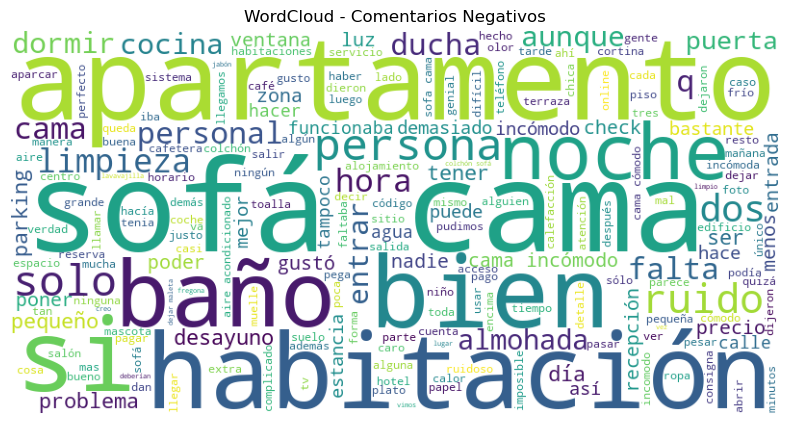

In [39]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

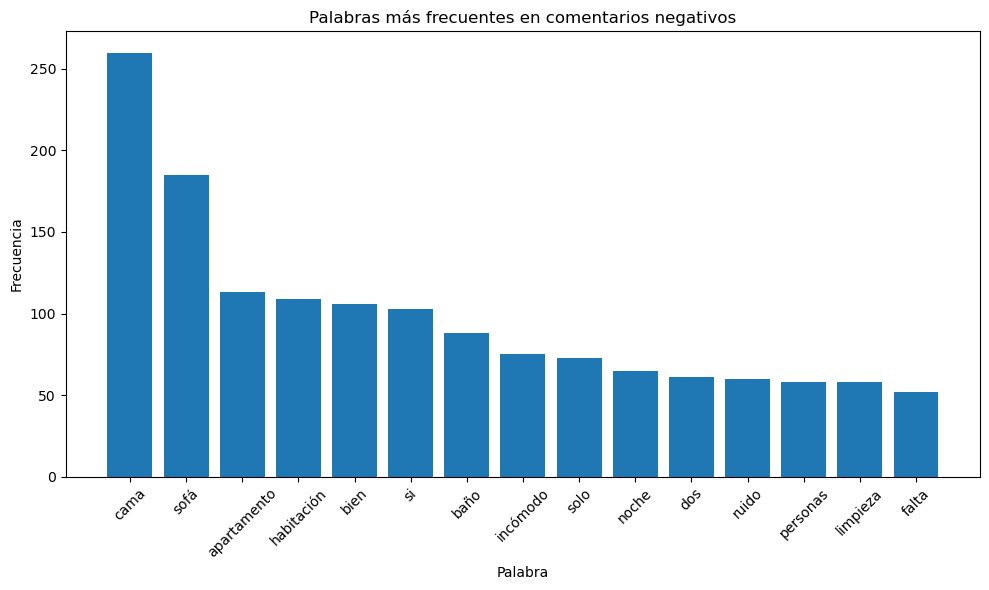

In [40]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()